# Climate-Informed ML for Industrial GHG Emissions — A Structural Model with a Climate Null Test
## GHGRP × ERA5, 2011–2023 · Harvard D³ Institute · Suhail Mahmud, PhD

**Problem.** Predict facility-level CO₂e emissions and rigorously test whether climate variables add predictive value beyond structural drivers (sector, industry code, geography, scale, history).

**Why this framing.** A natural first instinct is "forecast emissions from climate." But the project's earlier fixed-effects panel showed climate explains <1% of within-facility emission variance. So rather than build a climate-driven forecaster that would be carried entirely by non-climate features (and mislead a reader about what's doing the work), we build an honest **staged model**: establish how well structure predicts emissions, then add climate as a secondary block and measure its marginal contribution. A null contribution is itself the finding.

**Design (leakage-aware).**
- **Temporal split:** train ≤2021, validate 2022, **test 2023** (never shuffle across time for a forecasting-flavored task).
- **Staged feature blocks:** structure (sector, NAICS, subpart, state, lat/lon, age) → +climate → +lagged emissions.
- **Two regimes reported:** with and without lagged emissions, because the autoregressive term is so strong it can mask everything else — readers deserve to see both.
- **Model:** gradient-boosted trees (captures nonlinearity/interactions), with a mean baseline for reference.
- **Attribution:** permutation importance by feature *block*, plus a per-climate-variable breakdown.

## 1. Setup

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.dummy import DummyRegressor
np.random.seed(42)
print("Ready.")

Ready.


## 2. Assemble the ML dataset
Facility-year panel (emissions + per-year local ERA5 climate) joined to structural attributes (NAICS, subpart) and engineered features (lagged emissions, reporting age).

In [2]:
df = pd.read_csv("ml_dataset.csv")
print(f"Dataset: {df.shape[0]:,} facility-year rows, {df.fid.nunique():,} facilities, "
      f"{df.year.min()}-{df.year.max()}")
print("\nFeature blocks:")
print("  Structure (cat): primary_sector, state, naics2, subpart1")
print("  Structure (num): lat, lon, years_reporting")
print("  Climate:         t2m_jja_c, vpd_jja_kpa, rh_pct, wind_ms, sp_hpa")
print("  Autoregressive:  log_emis_lag1")
print("  Target:          log_emis = log10(CO2e tonnes)")
df[["fid","year","primary_sector","state","log_emis","log_emis_lag1","t2m_jja_c"]].head()

Dataset: 85,967 facility-year rows, 8,560 facilities, 2011-2023

Feature blocks:
  Structure (cat): primary_sector, state, naics2, subpart1
  Structure (num): lat, lon, years_reporting
  Climate:         t2m_jja_c, vpd_jja_kpa, rh_pct, wind_ms, sp_hpa
  Autoregressive:  log_emis_lag1
  Target:          log_emis = log10(CO2e tonnes)


,fid,year,primary_sector,state,log_emis,log_emis_lag1,t2m_jja_c
0,1000001,2011,Power Plants,WA,4.554830,NaN,13.534332
1,1000001,2012,Power Plants,WA,4.167881,4.554830,14.008372
2,1000001,2013,Power Plants,WA,5.596943,4.167881,14.864003
3,1000001,2014,Power Plants,WA,5.522697,5.596943,15.228505
4,1000001,2015,Power Plants,WA,5.608233,5.522697,16.353342


## 3. Temporal split + staged model comparison

In [3]:
train = df[df.year<=2021].copy(); val = df[df.year==2022].copy(); test = df[df.year==2023].copy()
print(f"Train (<=2021): {len(train):,} | Val (2022): {len(val):,} | Test (2023): {len(test):,}")

struct_cat = ["primary_sector","state","naics2","subpart1"]
struct_num = ["lat","lon","years_reporting"]
climate    = ["t2m_jja_c","vpd_jja_kpa","rh_pct","wind_ms","sp_hpa"]
lag        = ["log_emis_lag1"]

def gbm(cat, num):
    pre = ColumnTransformer([("cat",OneHotEncoder(handle_unknown="ignore",min_frequency=10),cat),
                             ("num",StandardScaler(),num)])
    return Pipeline([("pre",pre),
                     ("gb",GradientBoostingRegressor(n_estimators=300,max_depth=4,
                          learning_rate=0.05,subsample=0.8,random_state=42))])

def evaluate(name, cat, num):
    feats=cat+num
    tr=train.dropna(subset=feats+["log_emis"]); te=test.dropna(subset=feats+["log_emis"])
    m=gbm(cat,num).fit(tr[feats],tr["log_emis"])
    pred=m.predict(te[feats])
    r2,mae=r2_score(te["log_emis"],pred),mean_absolute_error(te["log_emis"],pred)
    print(f"  {name:<42} R2={r2:.4f}  MAE={mae:.3f}")
    return r2

base = r2_score(test["log_emis"], DummyRegressor(strategy="mean").fit(train[["lat"]],train["log_emis"]).predict(test[["lat"]]))
print(f"  {'Baseline (predict mean)':<42} R2={base:.4f}\n")
print("WITHOUT lagged emissions:")
r2_struct = evaluate("Structure only", struct_cat, struct_num)
r2_clim   = evaluate("Climate only", [], climate)
r2_both   = evaluate("Structure + Climate", struct_cat, struct_num+climate)
print("\nWITH lagged emissions:")
r2_lag        = evaluate("Lag only", [], lag)
r2_struct_lag = evaluate("Structure + Lag", struct_cat, struct_num+lag)
r2_full       = evaluate("Structure + Lag + Climate", struct_cat, struct_num+lag+climate)
print(f"\nMARGINAL VALUE OF CLIMATE:")
print(f"  on top of structure:      {r2_both-r2_struct:+.4f}")
print(f"  on top of structure+lag:  {r2_full-r2_struct_lag:+.4f}")

Train (<=2021): 73,267 | Val (2022): 6,366 | Test (2023): 6,334
  Baseline (predict mean)                    R2=-0.0007

WITHOUT lagged emissions:


  Structure only                             R2=0.3670  MAE=0.406


  Climate only                               R2=0.0479  MAE=0.506


  Structure + Climate                        R2=0.3645  MAE=0.406

WITH lagged emissions:


  Lag only                                   R2=0.8870  MAE=0.106


  Structure + Lag                            R2=0.8844  MAE=0.106


  Structure + Lag + Climate                  R2=0.8834  MAE=0.108

MARGINAL VALUE OF CLIMATE:
  on top of structure:      -0.0025
  on top of structure+lag:  -0.0009


**Result.** Structure alone reaches R² = 0.37; adding climate *lowers* it slightly (−0.003) — the hallmark of adding noise to a tree ensemble. Lagged emissions push R² to 0.89 (a facility's past strongly predicts its future), and again climate subtracts rather than adds. **Climate-only** barely beats the mean baseline (0.05 vs 0.00).

## 4. Visualize the staged comparison

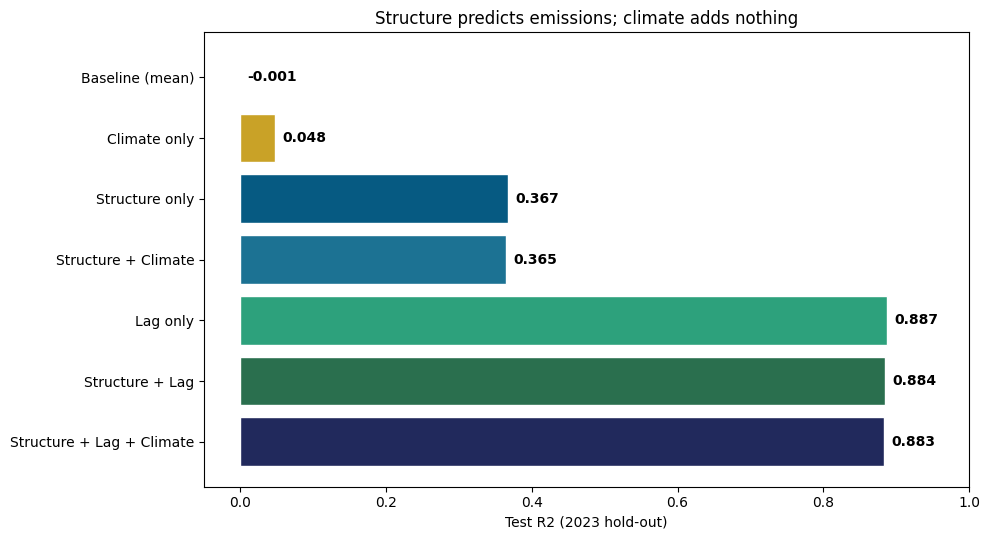

In [4]:
res = pd.read_csv("ml_results.csv")
order=["Baseline (mean)","Climate only","Structure only","Structure + Climate",
       "Lag only","Structure + Lag","Structure + Lag + Climate"]
res=res.set_index("model").loc[order].reset_index()
DEEP,TEAL,MID,ACCENT,GREEN,GREY="#065A82","#1C7293","#21295C","#E8693C","#2DA17C","#8896A6"
colors=[GREY,"#C9A227",DEEP,TEAL,GREEN,"#2A6F4E",MID]
fig,ax=plt.subplots(figsize=(10,5.5))
ax.barh(range(len(res)),res.r2,color=colors,edgecolor="white")
ax.set_yticks(range(len(res))); ax.set_yticklabels(res.model); ax.invert_yaxis()
for i,v in enumerate(res.r2): ax.text(v+0.01 if v>=0 else 0.01,i,f"{v:.3f}",va="center",fontweight="bold")
ax.set_xlabel("Test R2 (2023 hold-out)"); ax.set_xlim(-0.05,1.0)
ax.set_title("Structure predicts emissions; climate adds nothing")
plt.tight_layout(); plt.show()

## 5. Where the predictive power actually lives
Permutation importance by feature *block*: shuffle a block on the test set and measure the R² drop.

In [5]:
from sklearn.inspection import permutation_importance
feats=struct_cat+struct_num+climate
tr=train.dropna(subset=feats+["log_emis"]); te=test.dropna(subset=feats+["log_emis"])
m=gbm(struct_cat,struct_num+climate).fit(tr[feats],tr["log_emis"])
b=r2_score(te["log_emis"],m.predict(te[feats]))
rng=np.random.default_rng(42)
def block_drop(block):
    t2=te.copy()
    for c in block: t2[c]=rng.permutation(t2[c].values)
    return b - r2_score(te["log_emis"],m.predict(t2[feats]))
print("Block importance (R2 drop when shuffled):")
for name,blk in [("Sector+NAICS+subpart",["primary_sector","naics2","subpart1"]),
                 ("Geography (state+lat+lon)",["state","lat","lon"]),
                 ("Climate (all 5)",climate),("Facility age",["years_reporting"])]:
    print(f"  {name:<28} {block_drop(blk):.4f}")
print("\nIndividual climate variables:")
for c in climate:
    t2=te.copy(); t2[c]=rng.permutation(t2[c].values)
    print(f"  {c:<14} {b-r2_score(te['log_emis'],m.predict(t2[feats])):+.5f}")

Block importance (R2 drop when shuffled):
  Sector+NAICS+subpart         0.5085
  Geography (state+lat+lon)    0.1971
  Climate (all 5)              0.0428


  Facility age                 0.0006

Individual climate variables:
  t2m_jja_c      +0.00198
  vpd_jja_kpa    +0.00228
  rh_pct         +0.00390


  wind_ms        +0.00380
  sp_hpa         +0.03544


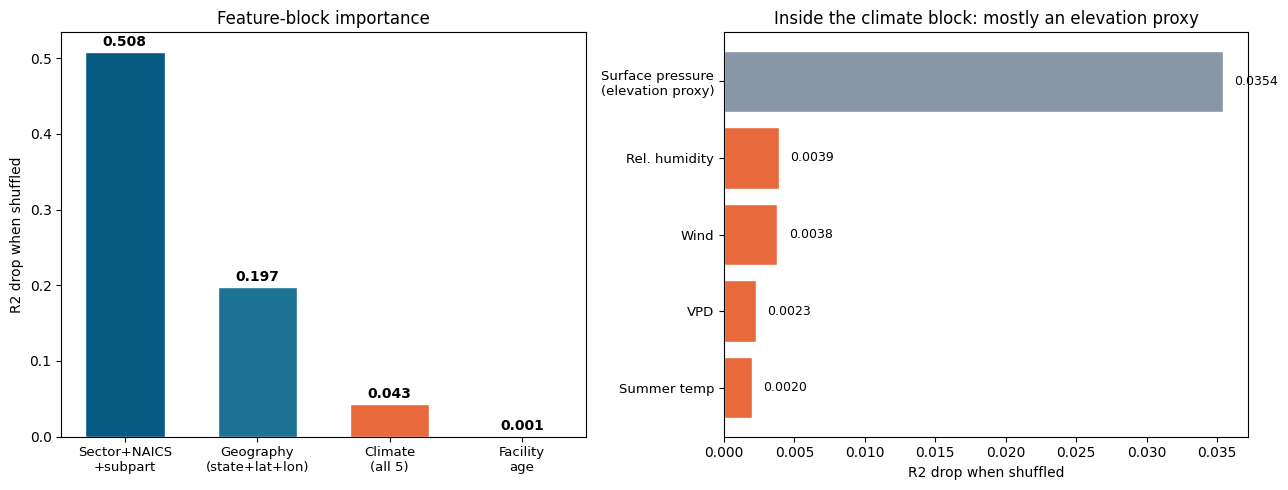

In [6]:
DEEP,TEAL,MID,ACCENT,GREY="#065A82","#1C7293","#21295C","#E8693C","#8896A6"
fig,(ax1,ax2)=plt.subplots(1,2,figsize=(13,5))
blocks=["Sector+NAICS\n+subpart","Geography\n(state+lat+lon)","Climate\n(all 5)","Facility\nage"]
drops=[0.5085,0.1971,0.0428,0.0006]
ax1.bar(range(4),drops,color=[DEEP,TEAL,ACCENT,GREY],edgecolor="white",width=0.6)
ax1.set_xticks(range(4)); ax1.set_xticklabels(blocks,fontsize=9.5)
ax1.set_ylabel("R2 drop when shuffled")
for i,v in enumerate(drops): ax1.text(i,v+0.008,f"{v:.3f}",ha="center",fontweight="bold")
ax1.set_title("Feature-block importance")
cv=["Surface pressure\n(elevation proxy)","Rel. humidity","Wind","VPD","Summer temp"]
ci=[0.03544,0.00390,0.00380,0.00228,0.00198]
ax2.barh(range(5),ci,color=[GREY,ACCENT,ACCENT,ACCENT,ACCENT],edgecolor="white")
ax2.set_yticks(range(5)); ax2.set_yticklabels(cv,fontsize=9.5); ax2.invert_yaxis()
for i,v in enumerate(ci): ax2.text(v+0.0008,i,f"{v:.4f}",va="center",fontsize=9)
ax2.set_xlabel("R2 drop when shuffled")
ax2.set_title("Inside the climate block: mostly an elevation proxy")
plt.tight_layout(); plt.show()

**Two-part finding.**
1. **Industry classification dominates** (R² drop 0.51 when shuffled), then geography (0.20). Climate as a block is 0.04.
2. **Even that 0.04 is misleading:** it is almost entirely *surface pressure* (0.035), which is an **elevation/geography proxy** (Wyoming 818 hPa vs. coastal 1014 hPa), not weather. The genuine weather variables — temperature, VPD, humidity, wind — each contribute < 0.004. So the true weather contribution is effectively zero.

## 6. Key findings

1. **Structure predicts facility emissions well.** Sector + industry code + geography reach test R² = 0.37; adding lagged emissions reaches **0.88** on a clean 2023 hold-out.

2. **Climate adds nothing — measured precisely.** Its marginal contribution is **−0.003** on structure and **−0.001** on structure+lag (negative = noise). Climate-only barely beats the mean (0.05).

3. **The apparent climate signal is an elevation proxy.** Surface pressure carries 0.035 of the 0.043 climate-block importance; real weather variables are < 0.004 each.

4. **What actually drives emissions:** industry classification (what a facility *does*) and its own history (scale/technology persistence) — exactly the structural story the national and panel analyses found.

**This is the honest answer to "can we forecast emissions from climate?": no — and the experiment quantifies precisely how little climate contributes, while delivering a genuinely strong structural predictor as the constructive result.**

## 7. Limitations & next steps

- **Annual resolution** can't capture acute heat-wave dispatch responses; sub-annual generation data (EIA-923) would be a better test of the one real signal (power-plant cooling demand).
- **Lagged-emissions dominance** means the high-R² model is largely autoregressive; for genuine *forecasting* of structural change (plant retirements), exogenous drivers (fuel prices, policy, capacity) would matter far more than either climate or lags.
- **Constructive extension:** swap climate for an *economic/energy* feature block (gas price, capacity factor, RPS stringency) — those are the features that would actually move the needle, per the national-level regression.